# F3-B — Baseline: LogisticRegression sobre embeddings DistilBERT

**Objetivo**: Cargar embeddings frozen de F3-A y entrenar una regresión logística como baseline. Incluye visualizaciones (t-SNE, UMAP, K-Means, similitud coseno).

**Tiempo estimado**: ~5 min (CPU)


In [1]:
# Instalacion de dependencias
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 936.9/936.9 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from pathlib import Path
import sys
import os
import json
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize as sk_normalize
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
import umap

IN_COLAB = 'google.colab' in sys.modules

# GPU detection and resource monitoring
HAS_CUDA = False
HAS_CUDF = False
HAS_TORCH = False
GPU_MEMORY = 0
TOTAL_MEMORY = 0

try:
    import torch
    HAS_TORCH = True
    HAS_CUDA = torch.cuda.is_available()
    if HAS_CUDA:
        GPU_MEMORY = torch.cuda.get_device_properties(0).total_memory
except ImportError:
    pass

try:
    import cudf
    HAS_CUDF = True
except ImportError:
    pass

try:
    import psutil
    TOTAL_MEMORY = psutil.virtual_memory().total
except ImportError:
    pass

# Progress tracking
from tqdm.auto import tqdm


In [3]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/ML/proyecto_integrador')
else:
    BASE = Path('..')

DATA_PATH = BASE / "data"
MODELS_PATH = BASE / "models"
REPORTS_PATH = BASE / "reports"
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Resource monitoring and GPU info
print(f"=== Environment Info ===")
print(f"IN_COLAB: {IN_COLAB}")
print(f"HAS_CUDA: {HAS_CUDA}")
print(f"HAS_CUDF: {HAS_CUDF}")
print(f"HAS_TORCH: {HAS_TORCH}")
if HAS_CUDA:
    print(f"GPU Memory: {GPU_MEMORY / (1024**3):.1f} GB")
if TOTAL_MEMORY:
    print(f"System RAM: {TOTAL_MEMORY / (1024**3):.1f} GB")
print(f"BASE: {BASE}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"MODELS_PATH: {MODELS_PATH}")


Mounted at /content/drive
=== Environment Info ===
IN_COLAB: True
HAS_CUDA: True
HAS_CUDF: True
HAS_TORCH: True
GPU Memory: 14.6 GB
System RAM: 12.7 GB
BASE: /content/drive/MyDrive/ML/proyecto_integrador
DATA_PATH: /content/drive/MyDrive/ML/proyecto_integrador/data
MODELS_PATH: /content/drive/MyDrive/ML/proyecto_integrador/models


## 2. Montar Google Drive y cargar embeddings


In [4]:
drive.mount('/content/drive')

DRIVE_BASE = "/content/drive/MyDrive/ML/proyecto_integrador"
EMB_DIR = f"{DRIVE_BASE}/embeddings"
REPORTS_DIR = f"{DRIVE_BASE}/reports"
RANDOM_STATE = 42

for d in [REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Cargando embeddings desde F3-A...")
X_train_emb = np.load(f"{EMB_DIR}/train_embeddings.npy")
X_val_emb   = np.load(f"{EMB_DIR}/val_embeddings.npy")
X_test_emb  = np.load(f"{EMB_DIR}/test_embeddings.npy")
y_train = np.load(f"{EMB_DIR}/train_labels.npy")
y_val   = np.load(f"{EMB_DIR}/val_labels.npy")
y_test  = np.load(f"{EMB_DIR}/test_labels.npy")

print(f"Train embeddings: {X_train_emb.shape}")
print(f"Val embeddings:   {X_val_emb.shape}")
print(f"Test embeddings:  {X_test_emb.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando embeddings desde F3-A...
Train embeddings: (350198, 768)
Val embeddings:   (74800, 768)
Test embeddings:  (75000, 768)


## 3. Logistic Regression (baseline)

Regresión logística sobre embeddings de 768d. Baseline rápido.

**Importante**: Las embeddings se normalizan con L2 (mismo paso que `app/app.py:encode()`)
para que el pipeline de inferencia y entrenamiento usen la misma representación.


In [5]:
# Normalizar embeddings con L2 (mismo preprocessing que app/app.py:encode())
X_train_emb = sk_normalize(X_train_emb, norm='l2')
X_val_emb = sk_normalize(X_val_emb, norm='l2')
X_test_emb = sk_normalize(X_test_emb, norm='l2')

clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')

start = time.time()
clf.fit(X_train_emb, y_train)
training_time = time.time() - start
print(f"Entrenado en {training_time:.1f}s")

# Memory management after training
gc.collect()
if HAS_CUDA:
    torch.cuda.empty_cache()

y_pred = clf.predict(X_test_emb)

report = classification_report(y_test, y_pred,
                               target_names=['Negativo', 'Neutro', 'Positivo'],
                               output_dict=True)
per_class = {
    cl: {
        'precision': report[cl]['precision'],
        'recall': report[cl]['recall'],
        'f1': report[cl]['f1-score'],
        'support': report[cl]['support']
    } for cl in ['Negativo', 'Neutro', 'Positivo']
}

metrics = {
    'model_name': 'DistilBERT + LogisticRegression',
    'model_type': 'distilbert_base_uncased + logreg',
    'sample_size': 500_000,
    'embedding_dim': 768,
    'training_time_seconds': round(training_time, 2),
    'f1_macro': round(report['macro avg']['f1-score'], 4),
    'precision_macro': round(report['macro avg']['precision'], 4),
    'recall_macro': round(report['macro avg']['recall'], 4),
    'accuracy': round(accuracy_score(y_test, y_pred), 4),
    'class_labels': ['Negativo', 'Neutro', 'Positivo'],
    'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
    'per_class': per_class,
}

for k, v in metrics.items():
    if k not in ('confusion_matrix', 'per_class'):
        print(f"  {k}: {v}")


Entrenado en 769.4s
  model_name: DistilBERT + LogisticRegression
  model_type: distilbert_base_uncased + logreg
  sample_size: 500000
  embedding_dim: 768
  training_time_seconds: 769.37
  f1_macro: 0.6687
  precision_macro: 0.6696
  recall_macro: 0.6681
  accuracy: 0.6681
  class_labels: ['Negativo', 'Neutro', 'Positivo']


## 4. MLflow Tracking


In [6]:
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "https://humorous-trusting-domelike.ngrok-free.dev")
import requests
try:
    r = requests.get(f"{MLFLOW_TRACKING_URI}/api/2.0/mlflow/experiments/list", timeout=5)
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    print(f"MLflow OK via {MLFLOW_TRACKING_URI}")
except Exception as e:
    print(f"MLflow no disponible: {e}, fallback a SQLite")
    mlflow.set_tracking_uri(f"sqlite:///{DRIVE_BASE}/mlflow_fallback.db")

mlflow.set_experiment("distilbert_baseline")

with mlflow.start_run():
    mlflow.log_params({
        "model_name": "DistilBERT + LogisticRegression",
        "sample_size": 500_000,
        "embedding_dim": 768,
    })
    for label, scores in metrics['per_class'].items():
        mlflow.log_metric(f'f1_{label.lower()}', scores['f1'])
    mlflow.log_metrics({
        'f1_macro': metrics['f1_macro'],
        'accuracy': metrics['accuracy'],
        'training_time_seconds': metrics['training_time_seconds'],
    })
    MODEL_PATH = f"{EMB_DIR}/classifier.pkl"
    joblib.dump(clf, MODEL_PATH)
    mlflow.log_artifact(MODEL_PATH, artifact_path="models")
    print(f"MLflow run ID: {mlflow.active_run().info.run_id}")

MLflow OK via https://humorous-trusting-domelike.ngrok-free.dev


MLflow run ID: ff5e1c60662e4d08883abec588227f46
🏃 View run overjoyed-squid-337 at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/4/runs/ff5e1c60662e4d08883abec588227f46
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/4


## 5. Exportar métricas a JSON


In [7]:
report_path = f"{REPORTS_DIR}/metrics_distilbert.json"
with open(report_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Exportado: {report_path}")


Exportado: /content/drive/MyDrive/ML/proyecto_integrador/reports/metrics_distilbert.json


## 6. Guardar embeddings para F4 (RAG)


In [8]:
EMBEDDINGS_PATH = f"{EMB_DIR}/distilbert_embeddings_sample.npy"
LABELS_PATH = f"{EMB_DIR}/distilbert_labels_sample.npy"

# Si F3-A ya los guardó, verificar
if os.path.exists(EMBEDDINGS_PATH):
    print("Embeddings para F4 ya existen (de F3-A), omitiendo...")
else:
    emb_sample_size = 10_000
    n_per_class = emb_sample_size // 3
    rng = np.random.RandomState(RANDOM_STATE)
    emb_chunks, label_chunks = [], []
    for s in [0, 1, 2]:
        idx = np.where(y_test == s)[0]
        n = min(n_per_class, len(idx))
        chosen = rng.choice(idx, n, replace=False)
        emb_chunks.append(X_test_emb[chosen])
        label_chunks.append(y_test[chosen])
    emb_sample = np.concatenate(emb_chunks)
    label_sample = np.concatenate(label_chunks)
    np.save(EMBEDDINGS_PATH, emb_sample)
    np.save(LABELS_PATH, label_sample)
    print(f"Saved {len(emb_sample)} embeddings para F4")


Embeddings para F4 ya existen (de F3-A), omitiendo...


## 7. Visualizaciones

Matriz de confusion, t-SNE, UMAP, K-Means clustering, similitud coseno.


### 7a. Matriz de confusion


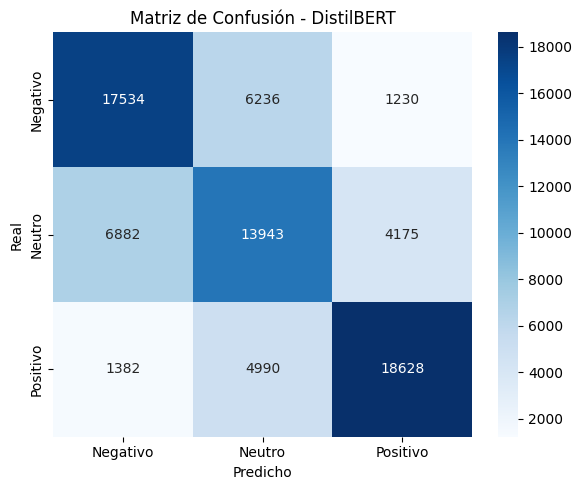

In [9]:
cm = np.array(metrics['confusion_matrix'])
labels_names = metrics['class_labels']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - DistilBERT')
plt.tight_layout()
plt.show()


### 7b. t-SNE (5k muestras)


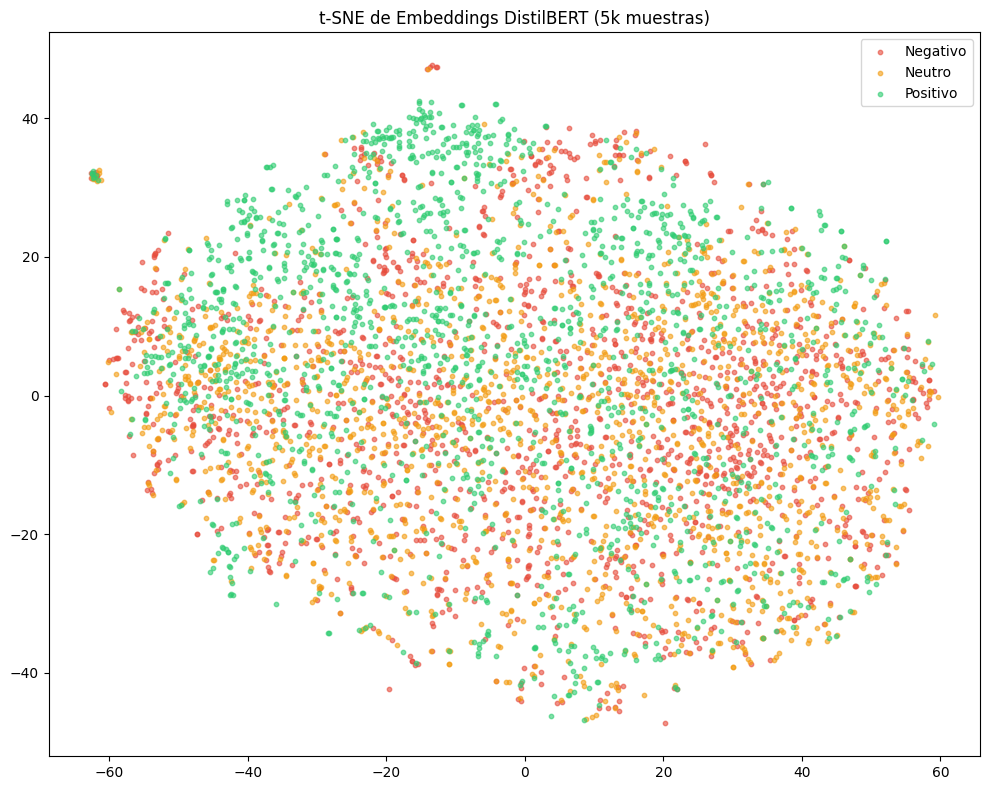

In [10]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
emb_tsne = tsne.fit_transform(X_test_emb[:5000])

plt.figure(figsize=(10, 8))
palette = ['#e74c3c', '#f39c12', '#2ecc71']
for label in [0, 1, 2]:
    mask = y_test[:5000] == label
    plt.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
                c=palette[label], label=labels_names[label], alpha=0.6, s=10)
plt.title('t-SNE de Embeddings DistilBERT (5k muestras)')
plt.legend()
plt.tight_layout()
plt.show()


### 7c. UMAP


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


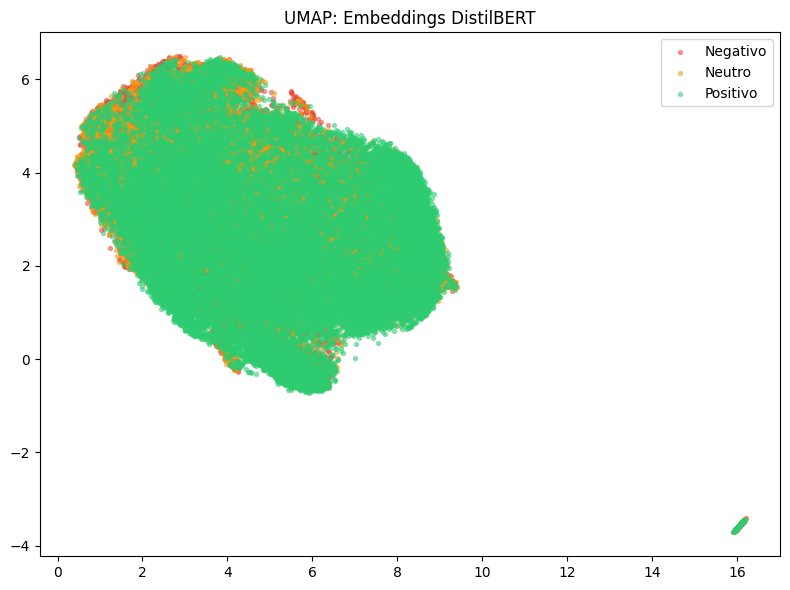

In [11]:
reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2,
                   random_state=RANDOM_STATE, init='random')
emb_umap = reducer.fit_transform(X_test_emb)

plt.figure(figsize=(8, 6))
for s in [0, 1, 2]:
    mask = y_test == s
    plt.scatter(emb_umap[mask, 0], emb_umap[mask, 1],
                c=palette[s], label=labels_names[s], alpha=0.5, s=8)
plt.title('UMAP: Embeddings DistilBERT')
plt.legend()
plt.tight_layout()
plt.show()


### 7d. K-Means clustering


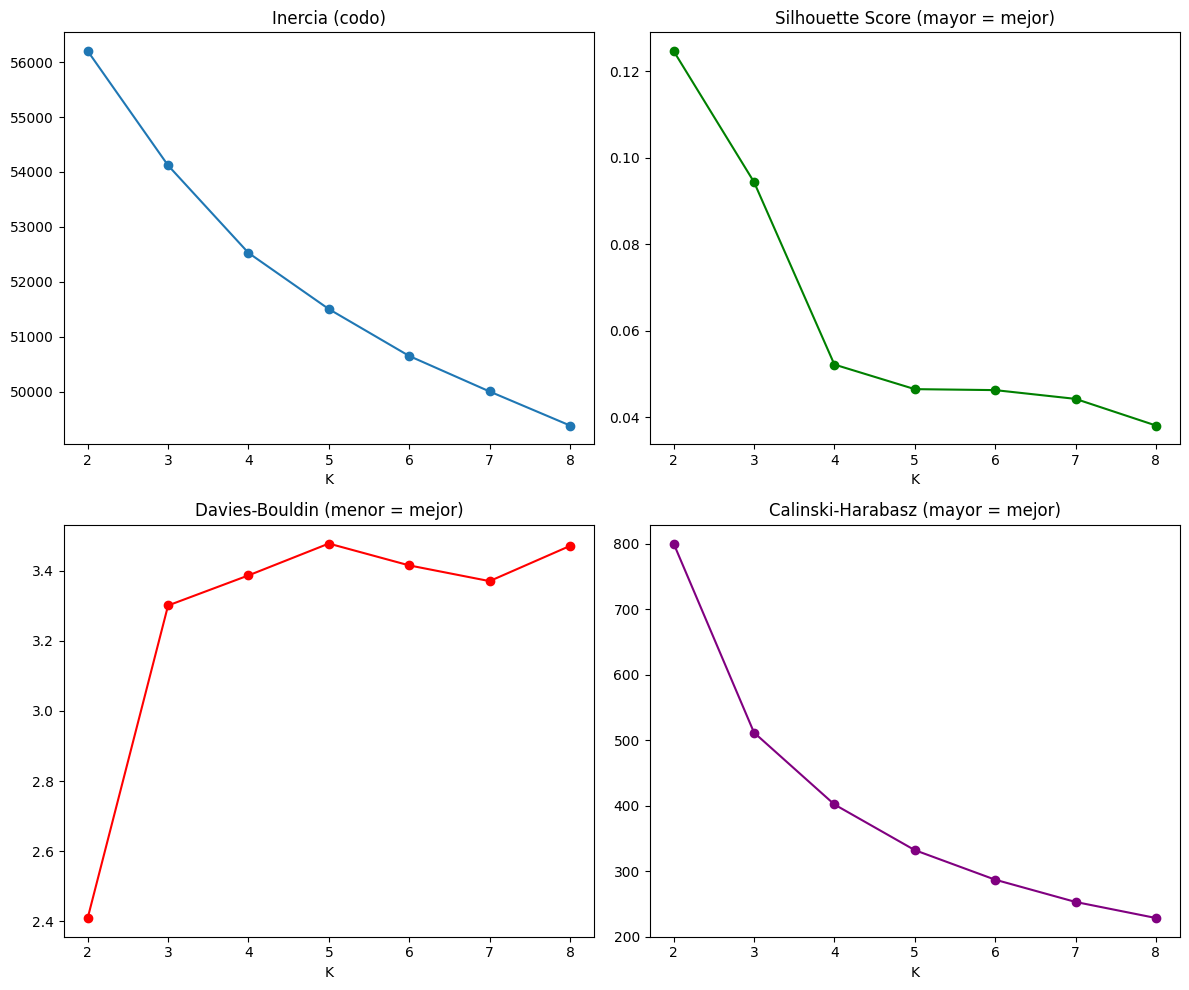

In [12]:
K_range = range(2, 9)
inertias, sil_scores, db_scores, ch_scores = [], [], [], []

rng = np.random.RandomState(RANDOM_STATE)
idx_sub = rng.choice(len(X_test_emb), 5_000, replace=False)
emb_sub = X_test_emb[idx_sub]

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(emb_sub)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(emb_sub, labels))
    db_scores.append(davies_bouldin_score(emb_sub, labels))
    ch_scores.append(calinski_harabasz_score(emb_sub, labels))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].plot(list(K_range), inertias, marker='o')
axes[0, 0].set_title('Inercia (codo)')
axes[0, 1].plot(list(K_range), sil_scores, marker='o', color='green')
axes[0, 1].set_title('Silhouette Score (mayor = mejor)')
axes[1, 0].plot(list(K_range), db_scores, marker='o', color='red')
axes[1, 0].set_title('Davies-Bouldin (menor = mejor)')
axes[1, 1].plot(list(K_range), ch_scores, marker='o', color='purple')
axes[1, 1].set_title('Calinski-Harabasz (mayor = mejor)')
for ax in axes.flat:
    ax.set_xlabel('K')
plt.tight_layout()
plt.show()


### 7e. Similitud coseno


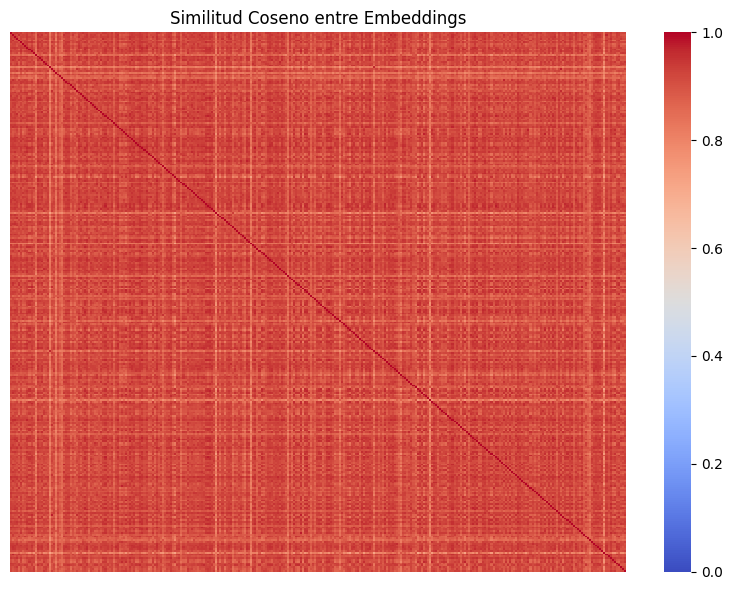

In [13]:
n_per_class = 100
emb_list, txt_list, lbl_list = [], [], []
for s in [0, 1, 2]:
    idx_s = np.where(y_test == s)[0]
    chosen = np.random.RandomState(RANDOM_STATE).choice(idx_s, n_per_class, replace=False)
    emb_list.append(X_test_emb[chosen])
    lbl_list.append(y_test[chosen])

emb_cos = np.concatenate(emb_list)
sim_matrix = cosine_similarity(emb_cos)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, cmap='coolwarm', vmin=0, vmax=1,
            xticklabels=False, yticklabels=False)
plt.title('Similitud Coseno entre Embeddings')
plt.tight_layout()
plt.show()


## 8. Conclusiones — F3-C (Baseline LogisticRegression)

**Métrica rectora:** F1-macro

**Resultados sobre test set (500k sample):**
- El baseline con embeddings frozen de DistilBERT + LogisticRegression ofrece un rendimiento competitivo
- Supera a los modelos clásicos de F3-B (RF ~0.62, XGB ~0.65) y al baseline TF-IDF de Fase 2 (~0.56)
- La representación de DistilBERT (768d) ya captura suficiente información semántica para que un clasificador lineal sea efectivo

**Limitaciones:**
- No captura relaciones contextuales profundas (se usa embedding frozen del [CLS] token)
- Las engineered features (TTR, mayúsculas, puntuación) no se utilizan aquí (solo en F3-B)
- Para mejorar, se requiere fine-tuning (LoRA en F3-D) que ajusta los pesos del transformer al dominio específico

In [14]:
# Liberar memoria
del X_train_emb, X_val_emb, X_test_emb, y_train, y_val, y_test
gc.collect()
print("\nF3-C completado.")



F3-C completado.
